<a href="https://colab.research.google.com/github/hafizzx/python-projects/blob/main/Simple_Linear_Regression_with_my_own_class.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [2]:
df = pd.read_csv("/content/students.csv")

df.head()

,cgpa,package
0,2.92,293803
1,1.67,131304
2,3.21,284382
3,1.26,50000
4,2.27,215420


In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 100
Columns: 2


In [4]:
df.tail()

,cgpa,package
95,1.84,156304
96,1.75,161467
97,3.58,338456
98,2.65,332864
99,3.51,372564


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   cgpa     100 non-null    float64
 1   package  100 non-null    int64  
dtypes: float64(1), int64(1)
memory usage: 1.7 KB


In [7]:
df.describe()

,cgpa,package
count,100.000000,100.000000
mean,2.425900,215868.180000
std,0.874392,106621.216519
min,1.000000,50000.000000
25%,1.667500,130366.500000
50%,2.410000,217500.500000
75%,3.190000,311056.500000
max,3.990000,400000.000000


In [9]:
df.isnull().sum()

,0
cgpa,0
package,0


In [11]:
df.dtypes

,0
cgpa,float64
package,int64


In [14]:
print("Average CGPA:",df["cgpa"].mean())

print("Average Salary:",df["package"].mean())

Average CGPA: 2.4259000000000004
Average Salary: 215868.18


In [15]:
print("Median CGPA:",
      df["cgpa"].median())

print("Median Salary:",
      df["package"].median())

Median CGPA: 2.41
Median Salary: 217500.5


In [17]:
print("Unique CGPA:",
      df["cgpa"].nunique())

print("Unique Salary:",
      df["package"].nunique())

Unique CGPA: 85
Unique Salary: 95


In [22]:
df[(df["cgpa"] >= 3.5)]

,cgpa,package
12,3.87,379123
14,3.54,310273
30,3.97,376166
32,3.53,348099
35,3.83,397270
36,3.63,342407
38,3.74,350705
41,3.69,396864
48,3.99,333393
49,3.58,338893


In [23]:
df[df["package"] > 300000]

,cgpa,package
10,3.42,325034
12,3.87,379123
14,3.54,310273
18,3.49,303934
20,3.11,313407
30,3.97,376166
32,3.53,348099
35,3.83,397270
36,3.63,342407
38,3.74,350705


In [29]:
fig = px.scatter(
    df,
    x="cgpa",
    y="package",
    title="Interactive CGPA vs Salary",
    hover_data=["cgpa", "package"]
)

fig.show()

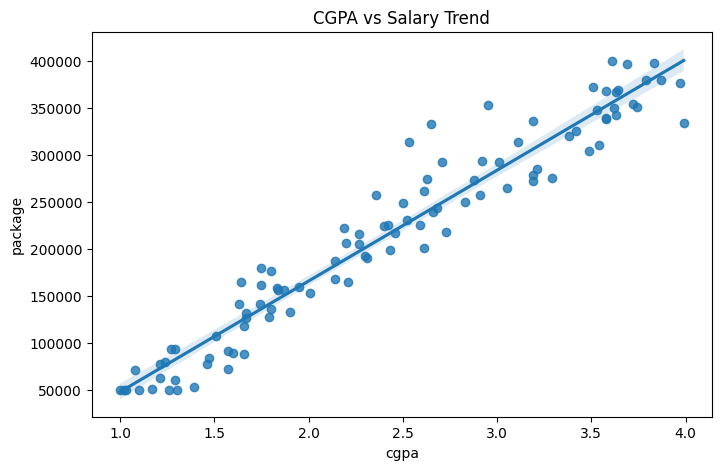

In [26]:
plt.figure(figsize=(8, 5))

sns.regplot(
    data=df,
    x="cgpa",
    y="package"
)

plt.title("CGPA vs Salary Trend")

plt.show()

In [34]:
fig = px.histogram(
    df,
    x="package",
    nbins=15,
    title="Salary Distribution"
)

fig.show()

**Linear Regression**

In [35]:
X = df["cgpa"].values
y = df["package"].values

In [36]:
print("X:", X[:5])
print("y:", y[:5])

X: [2.92 1.67 3.21 1.26 2.27]
y: [293803 131304 284382  50000 215420]


In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [38]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 80
Testing samples: 20


In [39]:
class MyLinearRegression:

    def __init__(self):

        self.m = None
        self.b = None

    def fit(self, X, y):

        X_mean = np.mean(X)
        y_mean = np.mean(y)

        numerator = np.sum(
            (X - X_mean) * (y - y_mean)
        )

        denominator = np.sum(
            (X - X_mean) ** 2
        )

        self.m = numerator / denominator

        self.b = y_mean - (
            self.m * X_mean
        )

    def predict(self, X):

        predictions = (
            self.m * X + self.b
        )

        return predictions

In [40]:
my_model = MyLinearRegression()

my_model.fit(
    X_train,
    y_train
)

In [41]:
print("Slope:", my_model.m)
print("Intercept:", my_model.b)

Slope: 119559.31473103423
Intercept: -73003.1373405304


In [42]:
my_predictions = my_model.predict(
    X_test
)

print(my_predictions[:10])

[286870.39999988 201983.28654085 217525.99745588 271327.68908485
  78837.19236788 135030.07029147  75250.41292595  71663.63348402
 335889.71903961 276110.06167409]


In [43]:
def calculate_mse(y_actual, y_predicted):

    error = y_actual - y_predicted

    squared_error = error ** 2

    mse = np.mean(squared_error)

    return mse

In [45]:
my_mse = calculate_mse(
    y_test,
    my_predictions
)


print("My Model MSE:", my_mse)


My Model MSE: 349483135.06298953


**Gradient Descent**

In [46]:
class MyGradientDescent:

    def __init__(
        self,
        learning_rate=0.01,
        epochs=1000
    ):

        self.learning_rate = learning_rate
        self.epochs = epochs

        self.m = 0
        self.b = 0

        self.cost_history = []

    def fit(self, X, y):

        n = len(X)

        for epoch in range(self.epochs):

            # Prediction
            y_pred = (
                self.m * X + self.b
            )

            # Error
            error = y_pred - y

            # Gradients
            dm = (
                (2 / n) *
                np.sum(X * error)
            )

            db = (
                (2 / n) *
                np.sum(error)
            )

            # Update parameters
            self.m = (
                self.m -
                self.learning_rate * dm
            )

            self.b = (
                self.b -
                self.learning_rate * db
            )

            # Cost
            cost = np.mean(
                error ** 2
            )

            self.cost_history.append(cost)

    def predict(self, X):

        return (
            self.m * X + self.b
        )

In [47]:
gd_model = MyGradientDescent(
    learning_rate=0.000000001,
    epochs=5000
)

In [48]:
gd_model.fit(
    X_train,
    y_train
)

In [49]:
print("Slope:", gd_model.m)
print("Intercept:", gd_model.b)

Slope: 6.0292083396438505
Intercept: 2.140205816449766


In [50]:
gd_predictions = gd_model.predict(
    X_test
)

print(gd_predictions[:10])

[20.28812292 16.007385   16.79118208 19.50432583  9.79730041 12.63102833
  9.61642416  9.43554791 22.76009834 19.74549417]


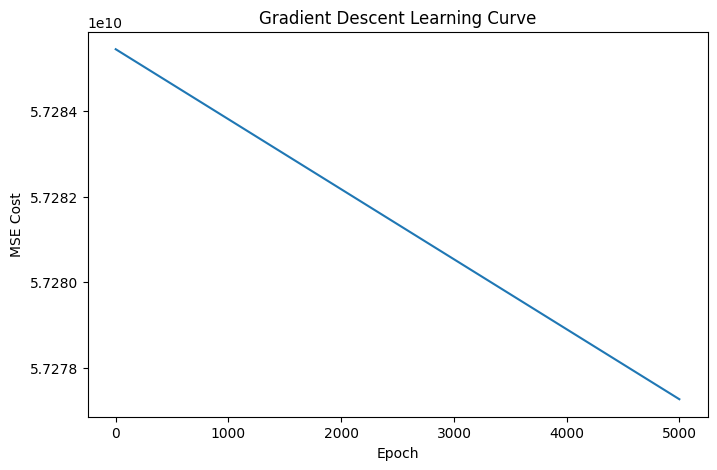

In [51]:
plt.figure(figsize=(8, 5))

plt.plot(
    gd_model.cost_history
)

plt.xlabel("Epoch")
plt.ylabel("MSE Cost")

plt.title(
    "Gradient Descent Learning Curve"
)

plt.show()